Your proposed summary table is strong for ICSME, and it maps well to what reviewers look for: performance, stability, and interpretability.

**Recommended Results Structure (ICSME-style)**

1. **RQ1: Which hyperparameters produce the best and most stable structures?**
2. **RQ2: How stable are learned dependencies across restarts/configs?**
3. **RQ3: What security-relevant relationships does the final BN reveal?**

If you only have space for 1-2 RQs, keep RQ1 and RQ3.

---

**Core Tables/Figures to Include**

1. **Table: Hyperparameter Tuning Summary**  
   Your idea is good. Use rows as `(mi_threshold, max_indegree)` and report selected `tabu_length`.
2. **Table: Final Model Characteristics (best config per MI)**  
   Include `n_edges`, `n_edges_on_target`, BIC, parent set of `is_vul`, top incoming edge strengths/frequencies.
3. **Figure: BIC Heatmap**  
   Axes: `tabu_length` and `max_indegree`, one panel per `mi_threshold`.
4. **Figure: Stability Plot**  
   `#restarts` vs best-so-far score and/or edge inclusion frequencies.
5. **Figure: Ego graph around `is_vul`**  
   Cleaner than full DAG for paper readability.

---

**Your Proposed Table: Refined Version**

Use this schema:

- **Rows**: `(mi_threshold, max_indegree)` combinations  
- **Columns**:
  - `selected_tabu_length`
  - `best_mean_BIC` (across restarts for selected tabu)
  - `BIC_std`
  - `n_unique_DAGs`
  - `mean_pairwise_SHD`
  - `mean_edge_count`
  - `n_restarts` (important context; usually 50)

This is publishable and concise.

---

**Small but Important Improvements**

1. Define **selection rule** clearly:  
   `selected_tabu_length = argmax mean_BIC` per `(mi_threshold, max_indegree)`.
2. Add a **tie-breaker rule**:  
   choose smaller `tabu_length`, then lower `mean_pairwise_SHD`.
3. Specify SHD variant:  
   directed SHD on DAGs (or CPDAG SHD if you use equivalence classes).
4. Report uncertainty:  
   mean ± std is fine; median + IQR can be added in appendix if skewed.

---

**Suggested Results Section Headings**

1. `5.1 Hyperparameter Sensitivity and Selection`
2. `5.2 Structural Stability Across Restarts`
3. `5.3 Interpreting Vulnerability-Related Dependencies`
4. `5.4 Robustness Checks` (optional but appreciated by reviewers)

If you want, I can draft the exact LaTeX table skeleton and a short “Results narrative template” tailored to your current `mi50/mi100` outputs.

In [1]:
from pathlib import Path
import json
import pandas as pd

from diff_analysis.utils.config_utils import find_project_root

In [2]:
project_root = find_project_root()
data_dir = project_root / "data/results/paper"
mi50_dir = data_dir / "mi50"
mi100_dir = data_dir / "mi100"

for experiment_dir in [mi50_dir, mi100_dir]:
    if not experiment_dir.exists():
        print(f"Experiment directory {experiment_dir} does not exist.")

# MI 50 experiments

In [3]:
tuning_metadata = mi50_dir / "experiment.json"


with open(tuning_metadata) as f:
    tuning_metadata = json.load(f)

tuning_metadata

{'script': 'diff_analysis.scripts.megavul.bn1.tune_bn1',
 'grid': {'mi_threshold': [50, 100, 200],
  'tabu_length': [10, 50, 100],
  'max_indegree': [None, 3, 5]},
 'hcs_params': {'delta': 0.05, 'c': 0.1, 'max_restarts': 50},
 'fixed_params': {'scoring': 'bic-d',
  'max_iter': 1000000,
  'feature_threshold': 0.0001,
  'sample_threshold': 0.0,
  'target_col': 'is_vul'},
 'n_configs': 27,
 'max_restarts_per_config': 50,
 'max_total_restarts': 1350}

Load results summary

In [4]:
results_summary = mi50_dir / 'summary.csv'
if results_summary.exists():
    results_summary = pd.read_csv(results_summary)
else:
    raise FileNotFoundError(f"Results summary {results_summary} does not exist.")

results_summary

,config_index,mi_threshold,tabu_length,max_indegree,started_at,ended_at,n_restarts_used,n_distinct_optima,n_edges,bic_score,n_edges_on_target,elapsed_s,error
0,1,50,10,NaN,2026-03-03T22:50:55,2026-03-03T22:56:38,50,45,69,-24095.95,31,342.8,NaN
1,2,50,10,3.0,2026-03-03T22:56:38,2026-03-03T23:02:09,50,45,69,-24095.95,31,330.6,NaN
2,3,50,10,5.0,2026-03-03T23:02:09,2026-03-03T23:07:53,50,45,69,-24095.95,31,344.1,NaN
3,4,50,50,NaN,2026-03-03T23:07:53,2026-03-03T23:13:34,50,45,69,-24095.95,31,341.2,NaN
4,5,50,50,3.0,2026-03-03T23:13:34,2026-03-03T23:18:59,50,45,69,-24095.95,31,324.7,NaN
5,6,50,50,5.0,2026-03-03T23:18:59,2026-03-03T23:24:34,50,45,69,-24095.95,31,335.6,NaN
6,7,50,100,NaN,2026-03-03T23:24:34,2026-03-03T23:30:16,50,45,70,-24096.53,31,341.4,NaN
7,8,50,100,3.0,2026-03-04T09:06:20,2026-03-04T09:12:05,50,48,70,-24096.53,31,344.2,NaN
8,9,50,100,5.0,2026-03-20T18:26:05,2026-03-20T18:32:00,50,46,70,-24096.53,31,355.3,NaN


In [5]:
# Get the best restart for each configuration in an experiment and compute the Structural Hamming Distance (SHD) between the resulting graphs.

import itertools
import math
import numpy as np

def load_best_restart(config_dir: Path):
    restarts_file = config_dir / "hcs_restarts.jsonl"
    if not restarts_file.exists():
        return None

    rows = []
    with open(restarts_file) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))

    if not rows:
        return None

    best = max(rows, key=lambda r: r.get("score", -math.inf))
    edges = {tuple(edge) for edge in best.get("edges", [])}
    return {
        "config": config_dir.name,
        "restart": best.get("restart"),
        "score": best.get("score"),
        "edges": edges,
    }

def directed_shd(edges_a: set[tuple[str, str]], edges_b: set[tuple[str, str]], nodes: set[str]) -> int:
    dist = 0
    for u, v in itertools.combinations(sorted(nodes), 2):
        # 0 = no edge, 1 = u->v, -1 = v->u
        a_state = 1 if (u, v) in edges_a else (-1 if (v, u) in edges_a else 0)
        b_state = 1 if (u, v) in edges_b else (-1 if (v, u) in edges_b else 0)
        dist += int(a_state != b_state)
    return dist

def shd_stats_for_experiment(experiment_dir: Path):
    configs_dir = experiment_dir / "configs"
    best_graphs = []
    for config_dir in sorted(configs_dir.glob("*")):
        if config_dir.is_dir():
            best = load_best_restart(config_dir)
            if best is not None:
                best_graphs.append(best)

    if len(best_graphs) < 2:
        raise ValueError(
            f"Need at least 2 configs with restart data in {experiment_dir.name} to compute SHD."
        )

    all_nodes = set()
    for g in best_graphs:
        for u, v in g["edges"]:
            all_nodes.add(u)
            all_nodes.add(v)

    pairwise = []
    for g1, g2 in itertools.combinations(best_graphs, 2):
        shd = directed_shd(g1["edges"], g2["edges"], all_nodes)
        pairwise.append({
            "config_a": g1["config"],
            "config_b": g2["config"],
            "shd": shd,
        })

    pairwise_df = pd.DataFrame(pairwise).sort_values("shd", ascending=False).reset_index(drop=True)
    return {
        "experiment": experiment_dir.name,
        "n_configs": len(best_graphs),
        "n_pairs": len(pairwise_df),
        "mean_shd": float(np.mean(pairwise_df["shd"])),
        "var_shd": float(np.var(pairwise_df["shd"], ddof=0)),
        "pairwise_df": pairwise_df,
    }

stats_rows = []
pairwise_tables = {}
for experiment_dir in [mi50_dir, mi100_dir]:
    stats = shd_stats_for_experiment(experiment_dir)
    pairwise_tables[experiment_dir.name] = stats.pop("pairwise_df")
    stats_rows.append(stats)

shd_summary = pd.DataFrame(stats_rows)
shd_summary

,experiment,n_configs,n_pairs,mean_shd,var_shd
0,mi50,8,28,2.035714,4.963010
1,mi100,9,36,1.166667,2.138889


In [6]:
# Per-config SHD stats across restarts: compare each non-best restart DAG to the best DAG in the same config.

import numpy as np
import math

def _read_restarts_as_edge_sets(config_dir: Path):
    restarts_file = config_dir / "hcs_restarts.jsonl"
    if not restarts_file.exists():
        return []

    rows = []
    with open(restarts_file) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            row["edges"] = {tuple(edge) for edge in row.get("edges", [])}
            rows.append(row)
    return rows

def shd_to_best_per_config(experiment_dir: Path) -> pd.DataFrame:
    records = []
    configs_dir = experiment_dir / "configs"

    for config_dir in sorted(configs_dir.glob("*")):
        if not config_dir.is_dir():
            continue

        restarts = _read_restarts_as_edge_sets(config_dir)
        if not restarts:
            continue

        # In this pipeline, score is the BIC-style objective and is maximized.
        best_idx = max(range(len(restarts)), key=lambda i: restarts[i].get("score", -math.inf))
        best = restarts[best_idx]
        best_edges = best["edges"]

        all_nodes = set()
        for r in restarts:
            for u, v in r["edges"]:
                all_nodes.add(u)
                all_nodes.add(v)

        # Exclude the selected best restart itself from SHD-to-best aggregation.
        other_restarts = [r for i, r in enumerate(restarts) if i != best_idx]
        shd_vals = [
            directed_shd(r["edges"], best_edges, all_nodes)
            for r in other_restarts
        ]

        if shd_vals:
            mean_shd = float(np.mean(shd_vals))
            var_shd = float(np.var(shd_vals, ddof=0))
            min_shd = int(np.min(shd_vals))
            max_shd = int(np.max(shd_vals))
        else:
            mean_shd = float("nan")
            var_shd = float("nan")
            min_shd = None
            max_shd = None

        records.append({
            "experiment": experiment_dir.name,
            "config": config_dir.name,
            "n_restarts": len(restarts),
            "best_restart": best.get("restart"),
            "best_score": best.get("score"),
            "mean_shd_to_best": mean_shd,
            "var_shd_to_best": var_shd,
            "min_shd_to_best": min_shd,
            "max_shd_to_best": max_shd,
        })

    return pd.DataFrame(records).sort_values(["experiment", "config"]).reset_index(drop=True)

config_shd_summary = pd.concat(
    [shd_to_best_per_config(mi50_dir), shd_to_best_per_config(mi100_dir)],
    ignore_index=True,
 )
config_shd_summary

,experiment,config,n_restarts,best_restart,best_score,mean_shd_to_best,var_shd_to_best,min_shd_to_best,max_shd_to_best
0,mi50,001_mi50_tabu10_indegNone,50,11,-24095.947053,14.632653,15.579342,4,20
1,mi50,002_mi50_tabu10_indeg3,50,11,-24095.947053,14.693878,15.192003,4,20
2,mi50,003_mi50_tabu10_indeg5,50,11,-24095.947053,14.632653,15.579342,4,20
3,mi50,004_mi50_tabu50_indegNone,50,11,-24095.947053,14.632653,15.579342,4,20
4,mi50,005_mi50_tabu50_indeg3,50,11,-24095.947053,14.693878,15.192003,4,20
5,mi50,006_mi50_tabu50_indeg5,50,11,-24095.947053,14.632653,15.579342,4,20
6,mi50,007_mi50_tabu100_indegNone,50,30,-24096.534634,13.938776,14.424823,4,22
7,mi50,008_mi50_tabu100_indeg3,71,30,-24096.534634,12.571429,17.216327,3,20
8,mi100,001_mi100_tabu10_indegNone,50,47,-28609.169673,31.387755,39.257809,22,48
9,mi100,002_mi100_tabu10_indeg3,50,47,-28609.169673,31.367347,39.211995,22,48


In [7]:
# Save both SHD result tables to disk.

output_dir = data_dir
output_dir.mkdir(parents=True, exist_ok=True)

experiment_shd_path = output_dir / "shd_summary_across_configs.csv"
config_shd_path = output_dir / "shd_summary_within_config.csv"

shd_summary.to_csv(experiment_shd_path, index=False)
config_shd_summary.to_csv(config_shd_path, index=False)

print(f"Saved: {experiment_shd_path} ({len(shd_summary)} rows)")
print(f"Saved: {config_shd_path} ({len(config_shd_summary)} rows)")

Saved: /Users/zayan/Documents/code/mine/research-lm_error_analysis/data/results/paper/shd_summary_across_configs.csv (2 rows)
Saved: /Users/zayan/Documents/code/mine/research-lm_error_analysis/data/results/paper/shd_summary_within_config.csv (17 rows)


In [8]:
# Condition-level pandas table (one row per MI threshold).
# This table can be exported directly to CSV/JSONL.

import numpy as np


def _load_condition_summary(condition: str) -> pd.DataFrame:
    summary_path = data_dir / condition / "summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary file: {summary_path}")
    return pd.read_csv(summary_path)


def _pick_scalar(series: pd.Series):
    vals = series.dropna().tolist()
    return vals[0] if vals else np.nan


rows = []
for condition in ["mi50", "mi100"]:
    df = _load_condition_summary(condition)

    # Pairwise SHD over best DAG per config, computed earlier in the notebook.
    if "pairwise_tables" in globals() and condition in pairwise_tables:
        shd_vals = pairwise_tables[condition]["shd"].to_numpy(dtype=float)
    else:
        exp_dir = data_dir / condition
        shd_vals = shd_stats_for_experiment(exp_dir)["pairwise_df"]["shd"].to_numpy(dtype=float)

    restarts_col = "n_restarts_used" if "n_restarts_used" in df.columns else "n_restart"

    rows.append(
        {
            "condition": condition,
            "n_restarts": _pick_scalar(df[restarts_col]),
            "n_unique_dags": _pick_scalar(df["n_distinct_optima"]),
            "bic_mean": float(df["bic_score"].mean()),
            "bic_std": float(df["bic_score"].std(ddof=0)),
            "pairwise_shd_mean": float(np.mean(shd_vals)),
            "pairwise_shd_std": float(np.std(shd_vals, ddof=0)),
            "edge_count_mean": float(df["n_edges"].mean()),
            "edge_count_std": float(df["n_edges"].std(ddof=0)),
        }
    )

condition_summary = pd.DataFrame(rows)
condition_summary[["n_restarts", "n_unique_dags"]] = condition_summary[["n_restarts", "n_unique_dags"]].astype("Int64")

# Optional exports:
# out_csv = data_dir / "condition_summary.csv"
# out_jsonl = data_dir / "condition_summary.jsonl"
# condition_summary.to_csv(out_csv, index=False)
# condition_summary.to_json(out_jsonl, orient="records", lines=True)

condition_summary

,condition,n_restarts,n_unique_dags,bic_mean,bic_std,pairwise_shd_mean,pairwise_shd_std,edge_count_mean,edge_count_std
0,mi50,50,45,-24096.143333,0.273415,2.035714,2.227781,69.333333,0.471405
1,mi100,50,50,-28609.383333,0.399110,1.166667,1.462494,118.777778,0.415740


# Get the Best DAG

In [9]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display


def _find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


project_root = globals().get("project_root", _find_project_root())
results_root = project_root / "data" / "results"

config_result_files = sorted(results_root.glob("tune_bn1/*/configs/*/result.json"))
config_result_files += sorted(results_root.glob("paper/mi*/configs/*/result.json"))

config_rows = []
restart_rows = []

for result_path in config_result_files:
    result = json.loads(result_path.read_text())
    result["_result_path"] = str(result_path.relative_to(project_root))
    config_rows.append(result)

    hcs_path = result_path.with_name("hcs_restarts.jsonl")
    if not hcs_path.exists():
        continue

    for line in hcs_path.read_text().splitlines():
        if not line.strip():
            continue
        rec = json.loads(line)
        rec.update(
            {
                "mi_threshold": result.get("mi_threshold"),
                "tabu_length": result.get("tabu_length"),
                "max_indegree": result.get("max_indegree"),
                "_config_path": str(result_path.relative_to(project_root)),
                "_restart_path": str(hcs_path.relative_to(project_root)),
                "n_edges_restart": len(rec.get("edges", [])),
                "edge_key": tuple(tuple(edge) for edge in rec.get("edges", [])),
            }
        )
        restart_rows.append(rec)

config_df = pd.DataFrame(config_rows)
error_ok = config_df["error"].isna() | config_df["error"].astype(str).str.strip().isin(["", "None", "null"])
config_df = config_df[config_df["bic_score"].notna() & error_ok].copy()
config_df = config_df.sort_values(["bic_score", "n_edges"], ascending=[False, True]).reset_index(drop=True)

restarts_df = pd.DataFrame(restart_rows)
restarts_df = restarts_df.sort_values(["score", "n_edges_restart"], ascending=[False, True]).reset_index(drop=True)

best_restart = restarts_df.iloc[0]
best_score = float(best_restart["score"])
best_ties = restarts_df[restarts_df["score"] == best_score].copy()

best_dag_summary = pd.DataFrame(
    [
        {
            "best_score": best_score,
            "bic_score_rounded": float(config_df.iloc[0]["bic_score"]),
            "mi_threshold": int(best_restart["mi_threshold"]),
            "tabu_length": int(best_restart["tabu_length"]),
            "max_indegree": best_restart["max_indegree"],
            "restart": int(best_restart["restart"]),
            "n_edges": int(best_restart["n_edges_restart"]),
            "tied_winning_records": int(len(best_ties)),
            "unique_best_dags": int(best_ties["edge_key"].nunique()),
            "restart_file": best_restart["_restart_path"],
        }
    ]
)

print(f"Scanned {len(config_df)} valid configs and {len(restarts_df)} restart records.")
display(best_dag_summary)

top_configs = config_df[
    [
        "mi_threshold",
        "tabu_length",
        "max_indegree",
        "bic_score",
        "n_edges",
        "n_edges_on_target",
        "n_restarts_used",
        "n_distinct_optima",
        "_result_path",
    ]
].head(10)
display(top_configs)

best_dag_edges = pd.DataFrame(best_restart["edges"], columns=["source", "target"])
parents_of_is_vul = sorted(best_dag_edges.loc[best_dag_edges["target"] == "is_vul", "source"].tolist())
children_of_is_vul = sorted(best_dag_edges.loc[best_dag_edges["source"] == "is_vul", "target"].tolist())

print(f"Parents of is_vul ({len(parents_of_is_vul)}):")
print(parents_of_is_vul)
print()
print(f"Children of is_vul ({len(children_of_is_vul)}):")
print(children_of_is_vul)

best_dag_edges.head(20)

Scanned 31 valid configs and 1571 restart records.


,best_score,bic_score_rounded,mi_threshold,tabu_length,max_indegree,restart,n_edges,tied_winning_records,unique_best_dags,restart_file
0,-24095.947053,-24095.95,50,10,NaN,11,69,12,1,data/results/tune_bn1/20260303_225055/configs/...


,mi_threshold,tabu_length,max_indegree,bic_score,n_edges,n_edges_on_target,n_restarts_used,n_distinct_optima,_result_path
0,50,10,NaN,-24095.95,69,31,50,45,data/results/tune_bn1/20260303_225055/configs/...
1,50,10,3.0,-24095.95,69,31,50,45,data/results/tune_bn1/20260303_225055/configs/...
2,50,10,5.0,-24095.95,69,31,50,45,data/results/tune_bn1/20260303_225055/configs/...
3,50,50,NaN,-24095.95,69,31,50,45,data/results/tune_bn1/20260303_225055/configs/...
4,50,50,3.0,-24095.95,69,31,50,45,data/results/tune_bn1/20260303_225055/configs/...
5,50,50,5.0,-24095.95,69,31,50,45,data/results/tune_bn1/20260303_225055/configs/...
6,50,10,NaN,-24095.95,69,31,50,45,data/results/paper/mi50/configs/001_mi50_tabu1...
7,50,10,3.0,-24095.95,69,31,50,45,data/results/paper/mi50/configs/002_mi50_tabu1...
8,50,10,5.0,-24095.95,69,31,50,45,data/results/paper/mi50/configs/003_mi50_tabu1...
9,50,50,NaN,-24095.95,69,31,50,45,data/results/paper/mi50/configs/004_mi50_tabu5...


Parents of is_vul (3):
['insert-node_Assignment_Block', 'insert-node_If_Block', 'insert-node_Invocation_Block']

Children of is_vul (28):
['delete-node_Annotation_Method', 'delete-node_Annotation_Parameter', 'delete-node_BinaryOperator_If', 'delete-node_Block_If', 'delete-node_Catch_Try', 'delete-node_FieldRead_ConstructorCall', 'delete-node_If_Block', 'delete-node_Invocation_BinaryOperator', 'delete-node_Invocation_Block', 'delete-node_Invocation_ConstructorCall', 'delete-node_Invocation_Invocation', 'delete-node_Invocation_LocalVariable', 'delete-node_Parameter_Method', 'delete-node_TypeAccess_Invocation', 'delete-node_TypeReference_Invocation', 'delete-node_VirtualElement_Annotation', 'insert-node_Annotation_Method', 'insert-node_Annotation_Parameter', 'insert-node_BinaryOperator_If', 'insert-node_Block_If', 'insert-node_FieldRead_ConstructorCall', 'insert-node_Invocation_ConstructorCall', 'insert-node_Invocation_Invocation', 'insert-node_Invocation_LocalVariable', 'insert-node_Para

,source,target
0,delete-node_If_Block,delete-node_LocalVariable_Block
1,insert-node_If_Block,is_vul
2,insert-node_If_Block,insert-node_Invocation_Block
3,insert-node_Invocation_Block,insert-node_ConstructorCall_LocalVariable
4,insert-node_Invocation_Block,is_vul
5,delete-node_Invocation_Block,delete-node_LocalVariable_Block
6,delete-node_Invocation_Block,delete-node_If_Block
7,insert-node_LocalVariable_Block,insert-node_If_Block
8,insert-node_LocalVariable_Block,insert-node_VariableRead_Invocation
9,insert-node_LocalVariable_Block,insert-node_Invocation_Block


Saved full DAG figure to: /Users/zayan/Documents/code/mine/research-lm_error_analysis/data/paper/figures/best_dag_full_bnlearn.png


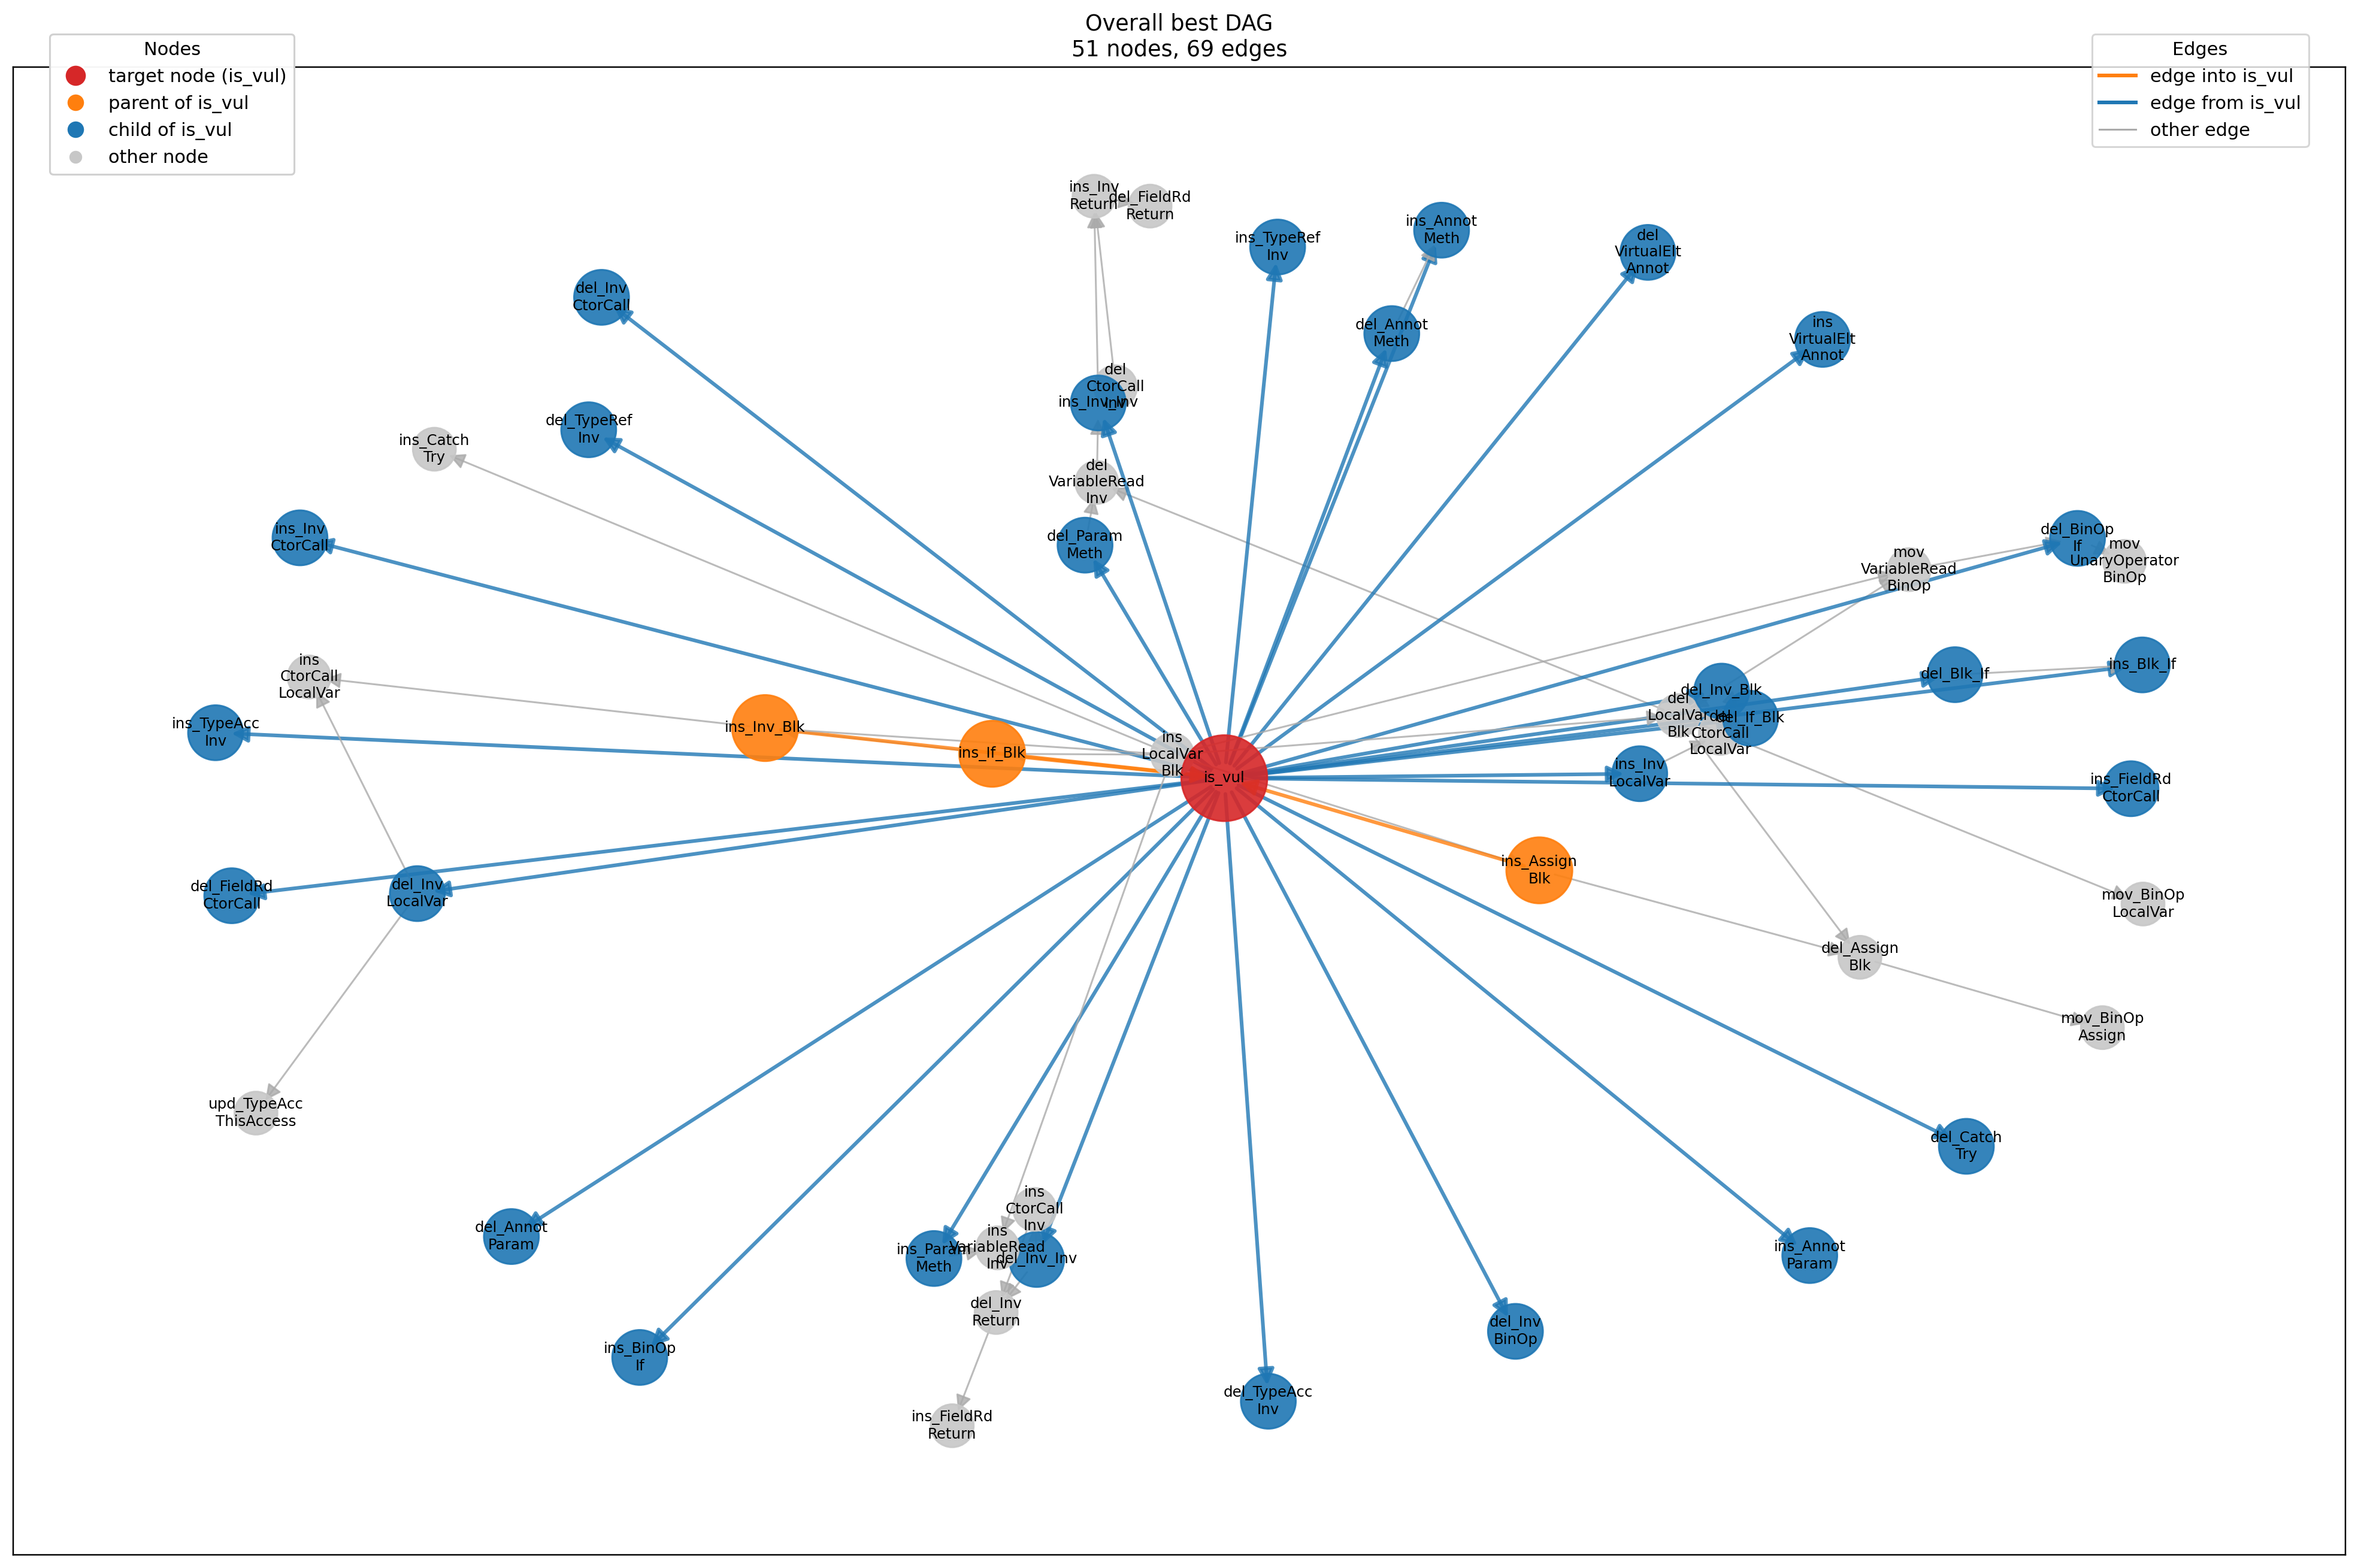

Saved ego DAG figure to: /Users/zayan/Documents/code/mine/research-lm_error_analysis/data/paper/figures/best_dag_ego_bnlearn.png


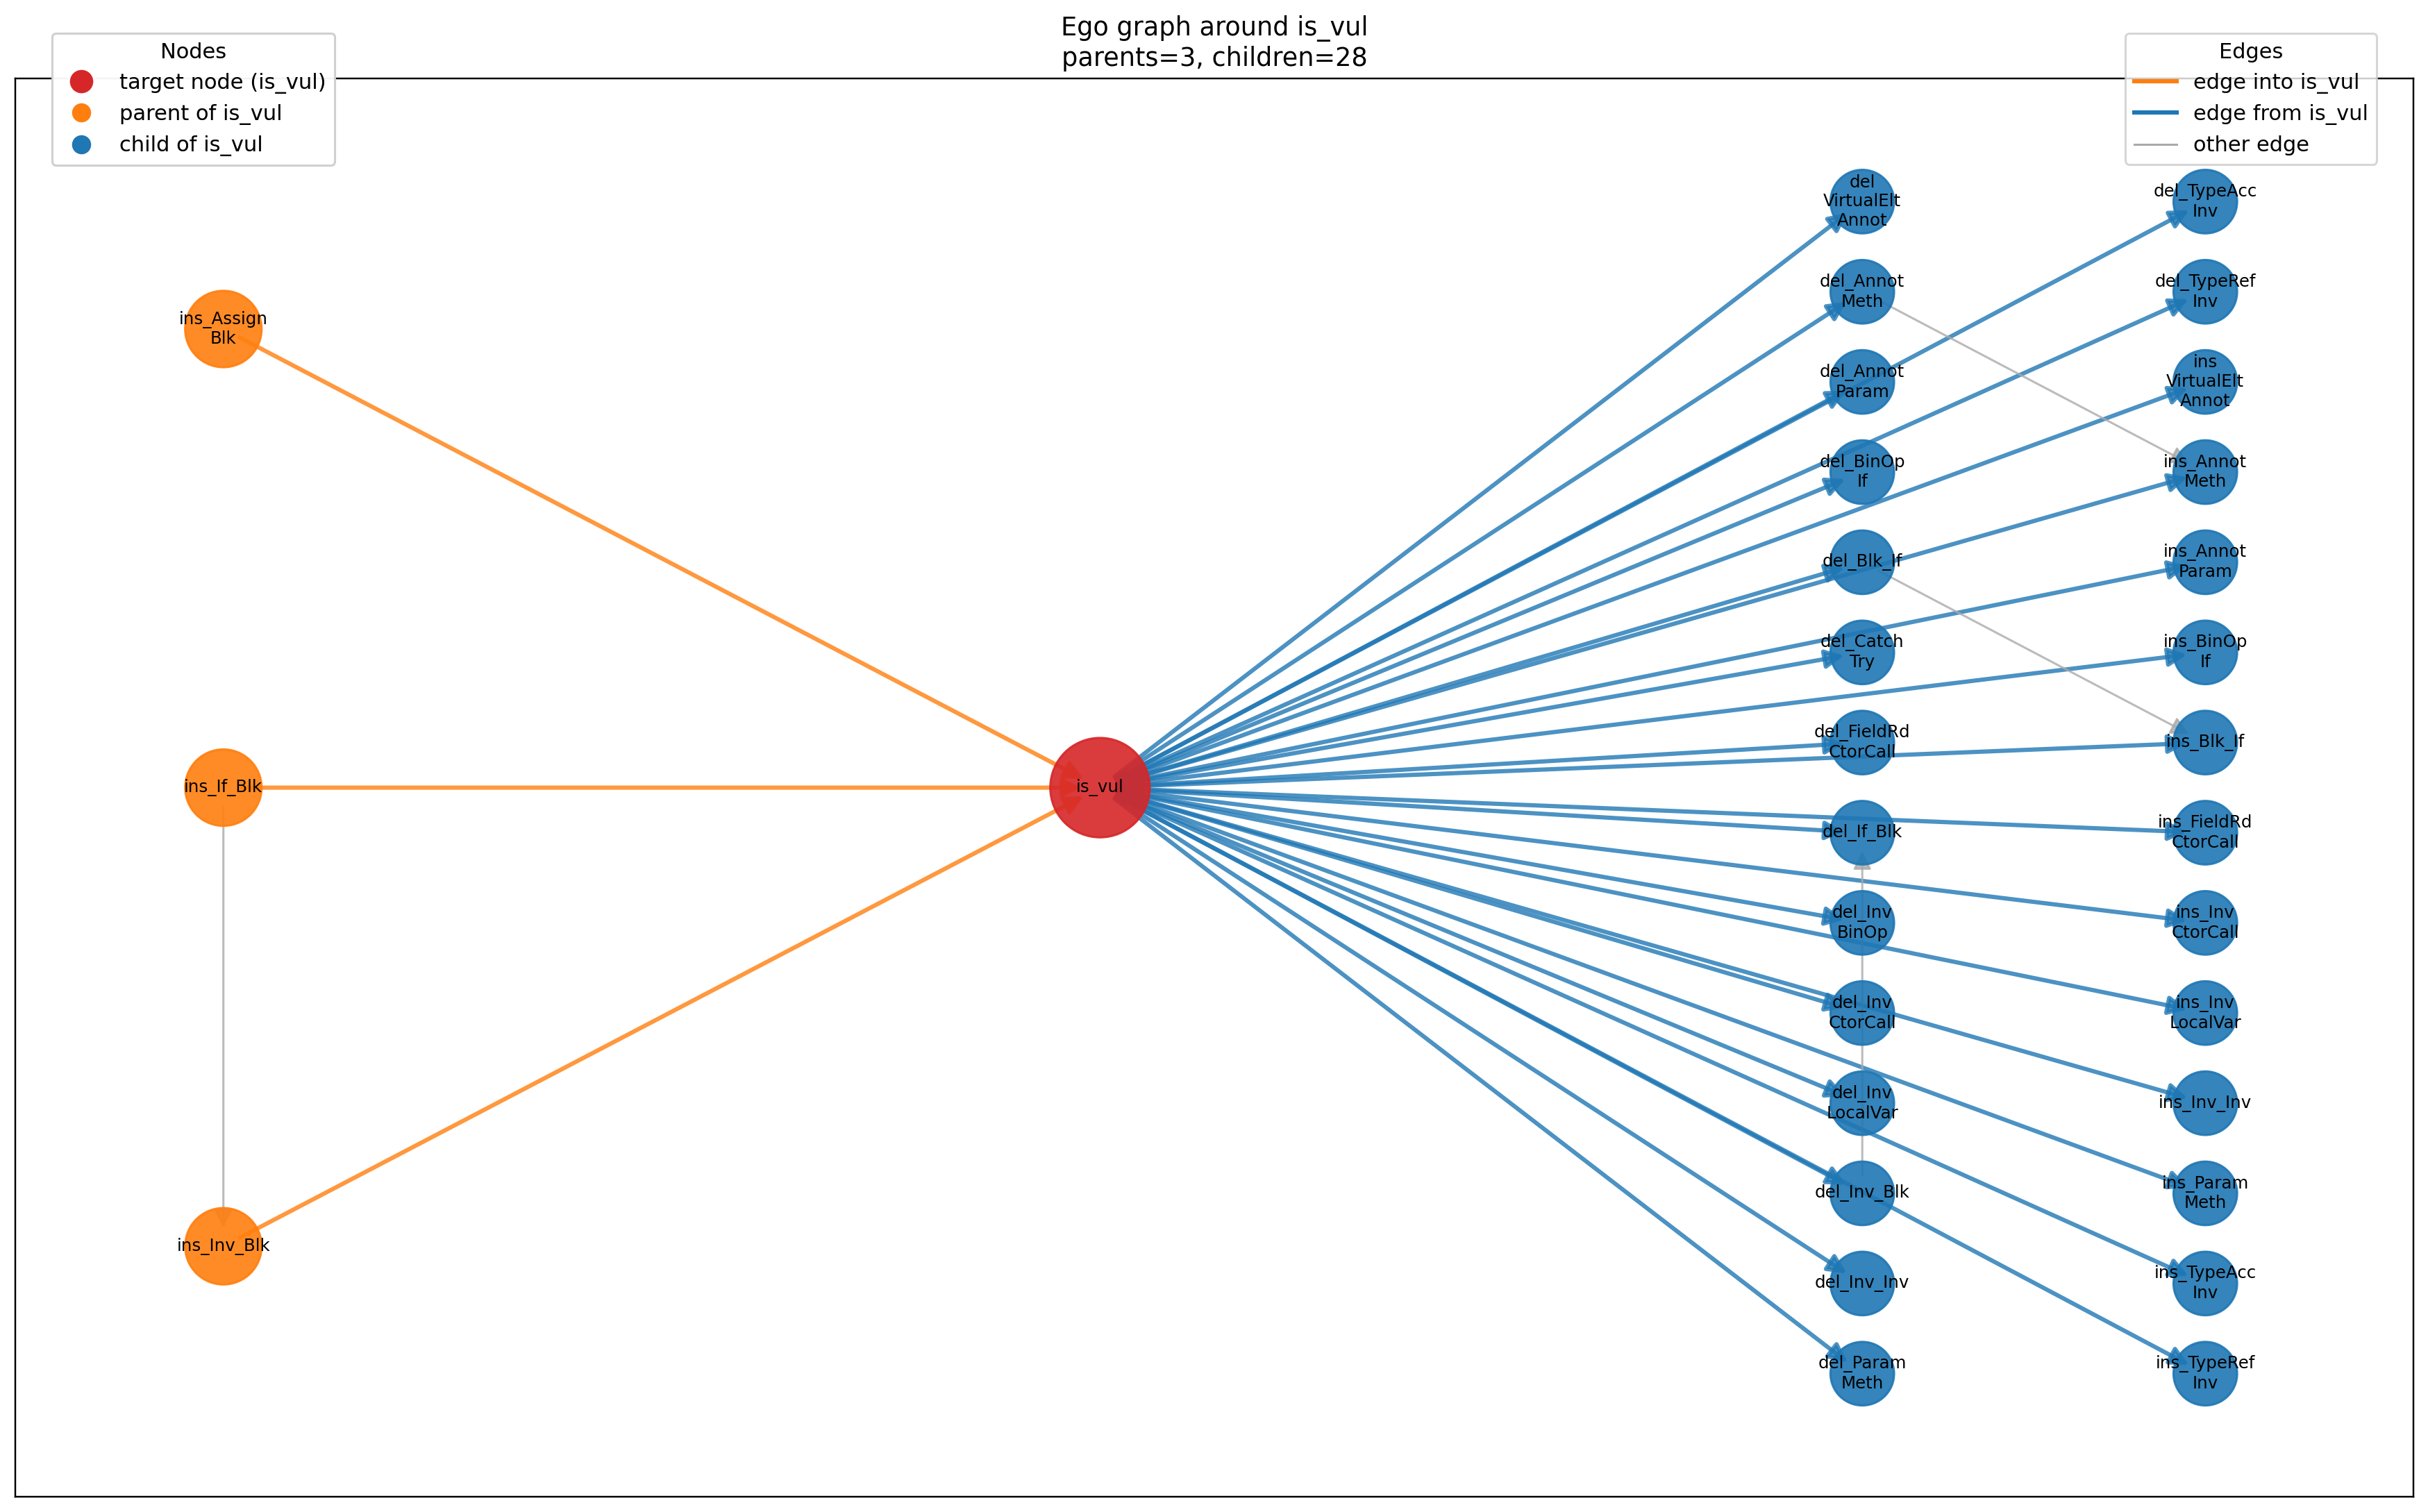

In [ ]:
# Visualize the overall best DAG using bnlearn.
# Note: bnlearn 0.10.x expects pgmpy's deprecated `BayesianNetwork`,
# so we patch it to `DiscreteBayesianNetwork` for compatibility.

import io
import warnings
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pgmpy.models as pgm

warnings.filterwarnings("ignore", category=SyntaxWarning)
pgm.BayesianNetwork = pgm.DiscreteBayesianNetwork

import bnlearn as bn

if hasattr(bn, "bnlearn") and hasattr(bn.bnlearn, "BayesianNetwork"):
    bn.bnlearn.BayesianNetwork = pgm.DiscreteBayesianNetwork

if "best_dag_edges" not in globals():
    raise RuntimeError("Run the previous cell first to compute `best_dag_edges`.")

LABEL_PREFIX_MAP = {
    "insert-node_": "ins_",
    "delete-node_": "del_",
    "move-tree_": "mov_",
    "update-node_": "upd_",
    "insert-tree_": "insT_",
    "delete-tree_": "delT_",
}

TOKEN_REPLACEMENTS = {
    "Invocation": "Inv",
    "ConstructorCall": "CtorCall",
    "LocalVariable": "LocalVar",
    "BinaryOperator": "BinOp",
    "Assignment": "Assign",
    "Parameter": "Param",
    "Annotation": "Annot",
    "TypeReference": "TypeRef",
    "TypeAccess": "TypeAcc",
    "VirtualElement": "VirtualElt",
    "FieldRead": "FieldRd",
    "Block": "Blk",
    "Method": "Meth",
}

ROLE_COLORS = {
    "target": "#d62728",
    "parent": "#ff7f0e",
    "child": "#1f77b4",
    "other": "#c7c7c7",
}

EDGE_COLORS = {
    "into_target": "#ff7f0e",  # matches parent node color
    "from_target": "#1f77b4",  # matches child node color
    "other": "#aaaaaa",        # neutral gray
}


def shorten_node_label(name: str) -> str:
    label = name
    for old, new in LABEL_PREFIX_MAP.items():
        if label.startswith(old):
            label = new + label[len(old):]
            break
    for old, new in TOKEN_REPLACEMENTS.items():
        label = label.replace(old, new)
    return label


def wrap_label(text: str, max_line_len: int = 11) -> str:
    parts = text.split("_")
    lines = []
    current = ""
    for part in parts:
        candidate = part if not current else f"{current}_{part}"
        if len(candidate) <= max_line_len:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = part
    if current:
        lines.append(current)
    return "\n".join(lines[:3])


original_nodes = sorted(set(best_dag_edges["source"]) | set(best_dag_edges["target"]))
label_map = {node: wrap_label(shorten_node_label(node)) for node in original_nodes}
label_map["is_vul"] = "is_vul"

plot_edges = [
    (label_map[src], label_map[dst])
    for src, dst in best_dag_edges[["source", "target"]].itertuples(index=False, name=None)
]

plot_target = label_map["is_vul"]
plot_parents = {label_map[src] for src in parents_of_is_vul}
plot_children = {label_map[dst] for dst in children_of_is_vul}


def node_role(node: str) -> str:
    if node == plot_target:
        return "target"
    if node in plot_parents:
        return "parent"
    if node in plot_children:
        return "child"
    return "other"


all_plot_nodes = sorted({n for edge in plot_edges for n in edge})
node_properties = {}
for node in all_plot_nodes:
    role = node_role(node)
    node_properties[node] = {
        "node_color": ROLE_COLORS[role],
        "node_size": 2200 if role == "target" else 1300 if role == "parent" else 900 if role == "child" else 550,
    }


def get_custom_edge_properties(model):
    with redirect_stdout(io.StringIO()):
        ep = bn.get_edge_properties(model)
    for (u, v) in ep:
        if v == plot_target:
            ep[(u, v)]["color"] = EDGE_COLORS["into_target"]
            ep[(u, v)]["weight"] = 2.0  # slightly thicker for visibility
        elif u == plot_target:
            ep[(u, v)]["color"] = EDGE_COLORS["from_target"]
            ep[(u, v)]["weight"] = 2.0
        else:
            ep[(u, v)]["color"] = EDGE_COLORS["other"]
            ep[(u, v)]["weight"] = 1.0
    return ep


legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="target node (is_vul)", markerfacecolor=ROLE_COLORS["target"], markersize=12),
    Line2D([0], [0], marker="o", color="w", label="parent of is_vul", markerfacecolor=ROLE_COLORS["parent"], markersize=10),
    Line2D([0], [0], marker="o", color="w", label="child of is_vul", markerfacecolor=ROLE_COLORS["child"], markersize=10),
    Line2D([0], [0], marker="o", color="w", label="other node", markerfacecolor=ROLE_COLORS["other"], markersize=8),
]

edge_legend_handles = [
    Line2D([0], [1], color=EDGE_COLORS["into_target"], lw=2, label="edge into is_vul"),
    Line2D([0], [1], color=EDGE_COLORS["from_target"], lw=2, label="edge from is_vul"),
    Line2D([0], [1], color=EDGE_COLORS["other"], lw=1, label="other edge"),
]


figure_dir = project_root / "data" / "results" / "paper" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# ----------------------
# 1) Full DAG with bnlearn
# ----------------------
with redirect_stdout(io.StringIO()):
    full_model = bn.make_DAG(plot_edges, checkmodel=False, verbose=0)
    full_edge_props = get_custom_edge_properties(full_model)
    full_plot = bn.plot(
        full_model,
        interactive=False,
        title=f"Overall best DAG\n{len(all_plot_nodes)} nodes, {len(plot_edges)} edges",
        node_properties=node_properties,
        edge_properties=full_edge_props,
        edge_labels=None,
        params_static={
            "layout": "graphviz_layout",
            "figsize": (18, 12),
            "font_size": 8,
            "font_family": "sans-serif",
            "alpha": 0.9,
            "edge_alpha": 0.8,  # Increased overall edge alpha so custom edge colors stand out
            "arrowstyle": "-|>",
            "arrowsize": 18,
            "showplot": False,
            "dpi": 220,
            "node_shape": "o",
        },
        verbose=0,
    )
fig_full = full_plot["fig"]

leg1_full = fig_full.legend(handles=legend_handles, loc="upper left", ncol=1, frameon=True, bbox_to_anchor=(0.02, 0.98), title="Nodes")
leg2_full = fig_full.legend(handles=edge_legend_handles, loc="upper right", ncol=1, frameon=True, bbox_to_anchor=(0.98, 0.98), title="Edges")
fig_full.add_artist(leg1_full)

fig_full.tight_layout(rect=[0, 0, 1, 1])
full_path = figure_dir / "best_dag_full_bnlearn.png"
fig_full.savefig(full_path, dpi=220, bbox_inches="tight")
print(f"Saved full DAG figure to: {full_path}")
plt.show()

# ----------------------
# 2) Ego graph around is_vul with bnlearn
# ----------------------
ego_nodes = {plot_target} | plot_parents | plot_children
ego_edges = [
    (src, dst)
    for src, dst in plot_edges
    if src in ego_nodes and dst in ego_nodes
]
ego_model = bn.make_DAG(ego_edges, checkmodel=False, verbose=0)

def _column_positions(names, x_values, y_top=1.2, y_bottom=-1.2):
    names = sorted(names)
    if not names:
        return {}
    chunks = np.array_split(names, len(x_values))
    pos = {}
    for x, chunk in zip(x_values, chunks):
        ys = np.linspace(y_top, y_bottom, len(chunk)) if len(chunk) > 1 else np.array([0.0])
        for name, y in zip(chunk, ys):
            pos[name] = (float(x), float(y))
    return pos


ego_pos = {plot_target: (0.0, 0.0)}
ego_pos.update(_column_positions(plot_parents, x_values=[-1.15], y_top=0.9, y_bottom=-0.9))
ego_pos.update(_column_positions(plot_children, x_values=[1.0, 1.45], y_top=1.15, y_bottom=-1.15))
ego_node_properties = {node: node_properties[node] for node in ego_nodes}

with redirect_stdout(io.StringIO()):
    ego_edge_props = get_custom_edge_properties(ego_model)
    ego_plot = bn.plot(
        ego_model,
        pos=ego_pos,
        interactive=False,
        title=f"Ego graph around is_vul\nparents={len(plot_parents)}, children={len(plot_children)}",
        node_properties=ego_node_properties,
        edge_properties=ego_edge_props,
        edge_labels=None,
        params_static={
            "layout": "spring_layout",
            "figsize": (16, 10),
            "font_size": 8,
            "font_family": "sans-serif",
            "alpha": 0.9,
            "edge_alpha": 0.8,
            "arrowstyle": "-|>",
            "arrowsize": 18,
            "showplot": False,
            "dpi": 220,
            "node_shape": "o",
        },
        verbose=0,
    )
fig_ego = ego_plot["fig"]

# Only include relevant node classes, but all edge classes
leg1_ego = fig_ego.legend(handles=legend_handles[:3], loc="upper left", ncol=1, frameon=True, bbox_to_anchor=(0.02, 0.98), title="Nodes")
leg2_ego = fig_ego.legend(handles=edge_legend_handles, loc="upper right", ncol=1, frameon=True, bbox_to_anchor=(0.98, 0.98), title="Edges")
fig_ego.add_artist(leg1_ego)

fig_ego.tight_layout(rect=[0, 0, 1, 1])
ego_path = figure_dir / "best_dag_ego_bnlearn.png"
fig_ego.savefig(ego_path, dpi=220, bbox_inches="tight")
print(f"Saved ego DAG figure to: {ego_path}")
plt.show()

### Neglected Edges
Mi50 graphs perform similarly to Mi100, indicating edges occuring in Mi100 but not Mi50 could be removed without affecting performance. The following code identifies these edges for the best Mi50 and Mi100 DAGs.

In [11]:
# Get most frequent edges across best DAGs in all configs of an experiment.
from collections import Counter

def best_edge_frequencies(experiment_dir: Path, top_n: int = 20):
    edge_counts = Counter()
    configs_dir = experiment_dir / "configs"
    n_configs_with_best = 0

    for config_dir in sorted(configs_dir.glob("*")):
        if not config_dir.is_dir():
            continue
        best = load_best_restart(config_dir)
        if best is None:
            continue
        n_configs_with_best += 1
        edge_counts.update(best["edges"])

    rows = []
    for edge, freq in edge_counts.most_common(top_n):
        rows.append({
            "experiment": experiment_dir.name,
            "edge": f"{edge[0]} -> {edge[1]}",
            "frequency": freq,
            "pct_configs": freq / n_configs_with_best if n_configs_with_best else float("nan"),
        })

    return pd.DataFrame(rows), n_configs_with_best

freq_tables = {}
for exp_dir in [mi50_dir, mi100_dir]:
    freq_df, n_configs = best_edge_frequencies(exp_dir, top_n=30)
    freq_tables[exp_dir.name] = freq_df
    print(f"{exp_dir.name}: {n_configs} configs with best DAGs")

freq_tables["mi100"].head(20)

mi50: 8 configs with best DAGs
mi100: 9 configs with best DAGs


,experiment,edge,frequency,pct_configs
0,mi100,insert-node_BinaryOperator_If -> move-tree_Bin...,9,1.0
1,mi100,move-tree_BinaryOperator_Invocation -> insert-...,9,1.0
2,mi100,delete-node_LocalVariable_TryWithResource -> m...,9,1.0
3,mi100,delete-node_LocalVariable_Block -> delete-node...,9,1.0
4,mi100,insert-node_VariableRead_Invocation -> move-tr...,9,1.0
5,mi100,is_vul -> insert-node_Invocation_ConstructorCall,9,1.0
6,mi100,delete-node_Invocation_Invocation -> insert-no...,9,1.0
7,mi100,move-tree_VariableRead_Conditional -> update-n...,9,1.0
8,mi100,insert-node_VariableRead_BinaryOperator -> del...,9,1.0
9,mi100,delete-node_LocalVariable_TryWithResource -> m...,9,1.0


In [12]:
# Export the edge frequency tables to JSON for use in the paper's visualizations.
import json

freq_tables_json = {k: v.to_dict(orient='records') for k, v in freq_tables.items()}

with open(output_dir / "freq_tables.json", "w") as f:
    json.dump(freq_tables_json, f, indent=2)

In [17]:
# Identify edges that appear in the top 30 most frequent edges of MI100 but not in MI50.
mi50_edges = set().union(*(g["edges"] for g in mi50_graphs))
mi100_edges = set().union(*(g["edges"] for g in mi100_graphs))

mi100_only_edges = sorted(mi100_edges - mi50_edges)

mi100_only_df = pd.DataFrame({
    "edge": [f"{u} -> {v}" for u, v in mi100_only_edges]
})
mi100_only_df

,edge
0,delete-node_Assignment_Block -> is_vul
1,delete-node_BinaryOperator_Return -> move-tree...
2,delete-node_FieldRead_ExecutableReferenceExpre...
3,delete-node_ForEach_Block -> update-node_Invoc...
4,delete-node_If_Block -> delete-node_VariableRe...
...,...
61,move-tree_Invocation_OperatorAssignment -> upd...
62,move-tree_VariableRead_BinaryOperator -> inser...
63,move-tree_VariableRead_BinaryOperator -> inser...
64,move-tree_VariableRead_Conditional -> update-n...


In [20]:
# Compute edge frequency across mi100 best DAGs and annotate the mi100-only edges dataframe.
mi100_edge_counts = Counter()
for g in mi100_graphs:
    mi100_edge_counts.update(g["edges"])

def edge_freq(edge_str: str) -> int:
    parts = edge_str.split(" -> ", maxsplit=1)
    return mi100_edge_counts.get((parts[0], parts[1]), 0) if len(parts) == 2 else 0

mi100_only_df["frequency"] = mi100_only_df["edge"].map(edge_freq)
mi100_only_df = mi100_only_df.sort_values(["frequency", "edge"], ascending=[False, True]).reset_index(drop=True)
mi100_only_df

,edge,frequency
0,delete-node_Assignment_Block -> is_vul,9
1,delete-node_BinaryOperator_Return -> move-tree...,9
2,delete-node_FieldRead_ExecutableReferenceExpre...,9
3,delete-node_ForEach_Block -> update-node_Invoc...,9
4,delete-node_If_Block -> delete-node_VariableRe...,9
...,...,...
61,move-tree_VariableRead_BinaryOperator -> inser...,9
62,move-tree_VariableRead_BinaryOperator -> inser...,9
63,move-tree_VariableRead_Conditional -> update-n...,9
64,update-node_VariableRead_Conditional -> insert...,9


In [21]:
# Export the MI100-only edges with frequencies to JSON for use in the paper's visualizations.
output_path = project_root / "data" / "results" / "paper"
output_path.mkdir(parents=True, exist_ok=True)

out_file = output_path / "mi100_only_df.json"
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(mi100_only_df.to_dict(orient="records"), f, indent=2)

out_file

PosixPath('/home/katelyn/research-explaining_vuln_fixes/data/results/paper/mi100_only_df.json')

In [22]:
# Calculate the ratio of mi50 edges that exist within mi100 graphs
intersection = mi50_edges & mi100_edges
ratio = len(intersection) / len(mi50_edges) if mi50_edges else 0
print(f"Ratio of mi50 edges in mi100: {ratio:.3f} ({len(intersection)} / {len(mi50_edges)})")

Ratio of mi50 edges in mi100: 0.733 (55 / 75)


In [23]:
# Identify edges that appear in MI50 but not in MI100 (opposite of what was done for MI100-only edges)
mi50_only_edges = sorted(mi50_edges - mi100_edges)

mi50_only_df = pd.DataFrame({
    "edge": [f"{u} -> {v}" for u, v in mi50_only_edges]
})

# Compute edge frequency across mi50 best DAGs
mi50_edge_counts = Counter()
for g in mi50_graphs:
    mi50_edge_counts.update(g["edges"])

def edge_freq_mi50(edge_str: str) -> int:
    parts = edge_str.split(" -> ", maxsplit=1)
    return mi50_edge_counts.get((parts[0], parts[1]), 0) if len(parts) == 2 else 0

mi50_only_df["frequency"] = mi50_only_df["edge"].map(edge_freq_mi50)
mi50_only_df = mi50_only_df.sort_values(["frequency", "edge"], ascending=[False, True]).reset_index(drop=True)

mi50_only_df

,edge,frequency
0,delete-node_Assignment_Block -> move-tree_Bina...,8
1,delete-node_If_Block -> delete-node_LocalVaria...,8
2,delete-node_Invocation_Block -> delete-node_Lo...,8
3,insert-node_Assignment_Block -> delete-node_As...,8
4,insert-node_Assignment_Block -> is_vul,8
5,insert-node_If_Block -> insert-node_Invocation...,8
6,insert-node_If_Block -> is_vul,8
7,insert-node_Invocation_Block -> insert-node_Co...,8
8,insert-node_Invocation_Block -> is_vul,8
9,insert-node_LocalVariable_Block -> delete-node...,8


In [24]:
output_path = project_root / "data" / "results" / "paper"
output_path.mkdir(parents=True, exist_ok=True)

out_file = output_path / "mi50_only_df.json"
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(mi50_only_df.to_dict(orient="records"), f, indent=2)

out_file

PosixPath('/home/katelyn/research-explaining_vuln_fixes/data/results/paper/mi50_only_df.json')

In [25]:
import pandas as pd

# Compute for each mi50 best DAG the ratio of its edges present in each mi100 best DAG
ratios = []
for i, mi50_g in enumerate(mi50_graphs):
    mi50_config = mi50_g['config']
    mi50_edges = mi50_g['edges']
    for j, mi100_g in enumerate(mi100_graphs):
        mi100_config = mi100_g['config']
        mi100_edges = mi100_g['edges']
        intersection = len(mi50_edges & mi100_edges)
        ratio = intersection / len(mi50_edges) if mi50_edges else 0
        ratios.append({
            'mi50_config': mi50_config,
            'mi100_config': mi100_config,
            'intersection_count': intersection,
            'mi50_edge_count': len(mi50_edges),
            'ratio': ratio
        })

ratios_df = pd.DataFrame(ratios)
ratios_df

,mi50_config,mi100_config,intersection_count,mi50_edge_count,ratio
0,001_mi50_tabu10_indegNone,001_mi100_tabu10_indegNone,50,69,0.724638
1,001_mi50_tabu10_indegNone,002_mi100_tabu10_indeg3,50,69,0.724638
2,001_mi50_tabu10_indegNone,003_mi100_tabu10_indeg5,50,69,0.724638
3,001_mi50_tabu10_indegNone,004_mi100_tabu50_indegNone,50,69,0.724638
4,001_mi50_tabu10_indegNone,005_mi100_tabu50_indeg3,50,69,0.724638
...,...,...,...,...,...
67,008_mi50_tabu100_indeg3,005_mi100_tabu50_indeg3,50,70,0.714286
68,008_mi50_tabu100_indeg3,006_mi100_tabu50_indeg5,50,70,0.714286
69,008_mi50_tabu100_indeg3,007_mi100_tabu100_indegNone,52,70,0.742857
70,008_mi50_tabu100_indeg3,008_mi100_tabu100_indeg3,50,70,0.714286
